# Geometric Shack–Hartmann wavefront sensing

**Scientific question.** Does a Shack–Hartmann sensor report equal x and y
responses to equal applied wavefront tilts, with the correct sign and negligible
cross-axis response? How close is the measured spot displacement to the
geometric prediction from the detector's angular pixel scale?

This tutorial uses the installed detector-level sensor with noise disabled.
The applied wavefront is a plane: OPD = tilt angle × pupil coordinate. The
angular gradient therefore has the requested value throughout the pupil.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.backends.native.shwfs import NativeShackHartmannOptics
from shwfs_ao.core.random import NamedRandomStreams
from shwfs_ao.detector.config import DetectorConfig
from shwfs_ao.wfs.shack_hartmann.geometry import build_shack_hartmann_geometry
from shwfs_ao.wfs.shack_hartmann.measurement import (
    build_detector_shack_hartmann_sensor,
)

SEED = 20240517
TELESCOPE_DIAMETER_M = 1.0
WFS_WAVELENGTH_M = 700e-9

## Configuration

In [3]:
geometry = build_shack_hartmann_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(64, 64),
    n_lenslets_across=8,
    min_fill_fraction=0.5,
)
optics = NativeShackHartmannOptics(geometry, WFS_WAVELENGTH_M, pad_factor=8)
sensor = build_detector_shack_hartmann_sensor(
    geometry,
    optics,
    DetectorConfig(photons_per_subap_frame=2e4),
    wfs_wavelength_m=WFS_WAVELENGTH_M,
    random_streams=NamedRandomStreams(SEED),
)
pupil = geometry.pupil_geometry
print(f"{geometry.n_subapertures} illuminated sub-apertures")

52 illuminated sub-apertures


## Simulation call

In [4]:
def slope_response(axis_name, amplitude_rad):
    coordinate_m = pupil.x_m if axis_name == "x" else pupil.y_m
    opd_m = np.where(geometry.pupil_mask, amplitude_rad * coordinate_m, 0.0)
    measurement = sensor.measure(
        opd_m,
        random_streams=NamedRandomStreams(SEED),
        include_noise=False,
    )
    assert np.all(measurement.vector.valid_rows), "Tilt fixture needs valid centroids."
    values = np.asarray(measurement.vector.values, dtype=float)
    return values[0::2], values[1::2]

applied_rad = 2.0e-6
expected_xy_px = applied_rad / np.asarray(optics.sampling.pixel_scale_rad)
tipx_x, tipx_y = slope_response("x", applied_rad)
tipy_x, tipy_y = slope_response("y", applied_rad)
coaxis_means = np.array([np.mean(tipx_x), np.mean(tipy_y)])
crossaxis_means = np.array([np.mean(tipx_y), np.mean(tipy_x)])
assert np.all(coaxis_means > 0.0)
assert np.allclose(coaxis_means, coaxis_means[0], rtol=1e-10, atol=1e-12)
assert np.all(np.abs(crossaxis_means) < 1e-10)
# Finite diffraction windows/centroiding permit a small optical-gain departure.
assert np.allclose(coaxis_means, expected_xy_px, rtol=0.1, atol=0.0)

## Diagnostic table

In [5]:
table = pd.DataFrame(
    [
        ("tip_x", applied_rad * 1e6, "x", np.mean(tipx_x), expected_xy_px[0]),
        ("tip_x", applied_rad * 1e6, "y", np.mean(tipx_y), 0.0),
        ("tip_y", applied_rad * 1e6, "x", np.mean(tipy_x), 0.0),
        ("tip_y", applied_rad * 1e6, "y", np.mean(tipy_y), expected_xy_px[1]),
    ],
    columns=["applied tilt", "angle (microrad)", "measured axis",
             "mean displacement (px)", "geometric prediction (px)"],
)
print("Co-axis measured / geometric gain:", coaxis_means / expected_xy_px)
table

Co-axis measured / geometric gain: [0.93049011 0.93049011]


,applied tilt,angle (microrad),measured axis,mean displacement (px),geometric prediction (px)
0,tip_x,2.0,x,2.700742e+00,2.902494
1,tip_x,2.0,y,1.366428e-16,0.000000
2,tip_y,2.0,x,5.807320e-15,0.000000
3,tip_y,2.0,y,2.700742e+00,2.902494


## Plot

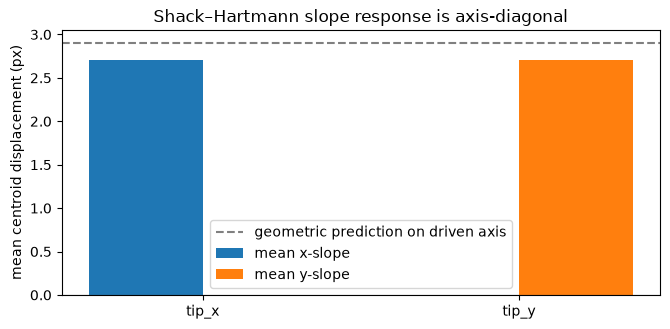

In [6]:
figure, axis = plt.subplots(figsize=(6.8, 3.4))
labels = ["tip_x", "tip_y"]
x_means = [np.mean(tipx_x), np.mean(tipy_x)]
y_means = [np.mean(tipx_y), np.mean(tipy_y)]
positions = np.arange(len(labels))
axis.bar(positions - 0.18, x_means, width=0.36, label="mean x-slope")
axis.bar(positions + 0.18, y_means, width=0.36, label="mean y-slope")
axis.axhline(expected_xy_px[0], color="0.5", linestyle="--",
             label="geometric prediction on driven axis")
axis.axhline(0.0, color="0.4", linewidth=0.8)
axis.set_xticks(positions)
axis.set_xticklabels(labels)
axis.set_ylabel("mean centroid displacement (px)")
axis.set_title("Shack–Hartmann slope response is axis-diagonal")
axis.legend()
figure.tight_layout()
plt.show()

## Interpretation

Equal 2 microradian x and y tilts produce equal positive displacements on the
driven axis and negligible mean displacement on the orthogonal axis. The table
also compares the centroid displacement with angle / angular pixel scale; the
printed gain shows the finite-window departure from the ideal geometric result.
The assertions check amplitude symmetry, sign, cross-axis leakage and a 10%
absolute-gain envelope for this configured sensor.

## Limitations

- Only planar tilts are exercised. Higher-order aberrations need separate tests.
- This is a diffraction-based detector sensor, so finite spot sampling and the
  centroid window can change the gain slightly.
- Noise is disabled here and is studied in `02_detector_centroiding.ipynb`.